# Simplified Virtual Try-On Model Training
## For Colab (GPU enabled)

This notebook trains a lightweight try-on model in hours on Colab free tier.
- **Training time**: 2-4 hours (10 epochs on ~500 images)
- **GPU**: Colab T4 (free) or P100 (Pro)
- **Output**: Trained model ready for FastAPI integration


## Step 1: Setup Environment

In [22]:
# Install dependencies
!pip install torch torchvision pillow tqdm -q

# Verify GPU
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.6 GB


## Step 2: Clone/Setup Project


In [23]:
# Clone from GitHub

!git clone https://github.com/kareemtahaaa/dollaby.git
%cd dollaby/backend

import os
print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Cloning into 'dollaby'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 198 (delta 62), reused 191 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 196.66 KiB | 5.46 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend
Current directory: /content/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend/dollaby/backend
Files: ['viton_service.py', 'calendar_routes.py', 'database.py', 'services', 'train_simple_viton.py', 'viton_inference.py', 'routers', 'Dockerfile', 'outfit_generator.py', 'README.md', 'auth.py', '.env.example', 'assistant.py', 'core', 'main.py', 'weather.py', 'requirements.txt', 'TRAINING_GUIDE.md', 'simple_viton_model.py', 'profile.py', 'models.py', 'Colab_Train_Simple_VITON.ipynb', '.dock

## Step 3: Download & Prepare Dataset


In [24]:
# Create missing training files if not in repo
import os
from pathlib import Path

files_needed = ["simple_viton_model.py", "train_simple_viton.py"]
missing_files = [f for f in files_needed if not Path(f).exists()]

if missing_files:
    print(f"Creating missing files: {missing_files}")
    
    # The files will be auto-created from backend directory
    # OR you can manually upload them from local machine
    print("\n⚠️  If files are missing:")
    print("1. Run: pip install torch torchvision (in step 1 if not done)")
    print("2. Upload simple_viton_model.py and train_simple_viton.py from your PC")
    print("3. Or paste the code into new files in Colab")
else:
    print("✓ All training files found!")
    
print(f"\nCurrent files: {os.listdir()}")

✓ All training files found!

Current files: ['viton_service.py', 'calendar_routes.py', 'database.py', 'services', 'train_simple_viton.py', 'viton_inference.py', 'routers', 'Dockerfile', 'outfit_generator.py', 'README.md', 'auth.py', '.env.example', 'assistant.py', 'core', 'main.py', 'weather.py', 'requirements.txt', 'TRAINING_GUIDE.md', 'simple_viton_model.py', 'profile.py', 'models.py', 'Colab_Train_Simple_VITON.ipynb', '.dockerignore', 'closet.py']


In [25]:
# Option A: Download VITON-HD (RECOMMENDED) - ~30GB, but we'll use subset
# This is the official dataset
# Download from: https://github.com/shadow2496/VITON-HD

# For quick testing, we'll create a synthetic dataset from a subset
import os
from pathlib import Path
import numpy as np
from PIL import Image

# Create dataset directories
data_dir = Path("/content/viton_data")
for subdir in ["person_images", "garment_images", "target_images"]:
    (data_dir / subdir).mkdir(parents=True, exist_ok=True)

print(f"Dataset directory created: {data_dir}")
print(f"Subdirectories: {list(data_dir.iterdir())}")

Dataset directory created: /content/viton_data
Subdirectories: [PosixPath('/content/viton_data/target_images'), PosixPath('/content/viton_data/garment_images'), PosixPath('/content/viton_data/person_images')]


In [26]:
# Option B: Use a smaller public dataset (for testing only)
# We'll download a small subset for demonstration

# For production training, download VITON-HD:
print("DATASET OPTIONS:")
print("\n1. VITON-HD (Recommended for full training):")
print("   - Download: https://github.com/shadow2496/VITON-HD")
print("   - Size: ~30GB")
print("   - Use this for best results\n")

print("2. For quick testing (create synthetic data):")
print("   - We can generate sample images below\n")

# Create 50 synthetic samples for quick test
import random
random.seed(42)

num_samples = 50  # Quick test set

for i in range(num_samples):
    # Create synthetic person image (full body)
    person = np.random.randint(100, 200, (512, 384, 3), dtype=np.uint8)
    Image.fromarray(person).save(data_dir / f"person_images/img_{i:04d}.jpg")

    # Create synthetic garment image
    garment = np.random.randint(50, 150, (256, 256, 3), dtype=np.uint8)
    Image.fromarray(garment).save(data_dir / f"garment_images/img_{i:04d}.jpg")

    # Create target (person + garment blend - simulated)
    target = (person * 0.7 + np.random.randint(50, 150, (512, 384, 3), dtype=np.uint8) * 0.3).astype(np.uint8)
    Image.fromarray(target).save(data_dir / f"target_images/img_{i:04d}.jpg")

print(f"✓ Created {num_samples} synthetic training samples for testing")
print(f"  Ready to train! For better results, replace with real VITON-HD dataset.")

DATASET OPTIONS:

1. VITON-HD (Recommended for full training):
   - Download: https://github.com/shadow2496/VITON-HD
   - Size: ~30GB
   - Use this for best results

2. For quick testing (create synthetic data):
   - We can generate sample images below

✓ Created 50 synthetic training samples for testing
  Ready to train! For better results, replace with real VITON-HD dataset.


## Step 4: Load and Test Model Architecture


In [27]:
# Import model
from simple_viton_model import SimplifiedVitonUNet, SimpleVitonTrainer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize model
model = SimplifiedVitonUNet()
print(f"Model created on device: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Size:")
print(f"  Total params: {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Size: ~{total_params * 4 / 1e6:.1f} MB")

# Test forward pass
dummy_person = torch.randn(1, 3, 256, 192).to(device)
dummy_garment = torch.randn(1, 3, 256, 192).to(device)
model = model.to(device)
output = model(dummy_person, dummy_garment)
print(f"\n✓ Forward pass successful: output shape = {output.shape}")

Model created on device: cuda

Model Size:
  Total params: 2,445,443
  Trainable params: 2,445,443
  Size: ~9.8 MB

✓ Forward pass successful: output shape = torch.Size([1, 3, 256, 192])


## Step 5: Train Model


In [28]:
from train_simple_viton import SimpleVitonDataset, SimpleVitonTrainer
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load dataset
print("Loading dataset...")
dataset = SimpleVitonDataset("/content/viton_data", split="train")
print(f"Dataset size: {len(dataset)} samples")

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
print(f"Batch size: 4")
print(f"Total batches per epoch: {len(dataloader)}")

# Initialize trainer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimplifiedVitonUNet()
trainer = SimpleVitonTrainer(model, device=device, save_dir="/content/models")

print(f"\n✓ Trainer initialized on {device}")

Loading dataset...
Dataset size: 50 samples
Batch size: 4
Total batches per epoch: 13

✓ Trainer initialized on cuda


In [29]:
# Train!
epochs = 5  # Quick test - use 10-20 for production

print(f"Starting training: {epochs} epochs...\n")

for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}/{epochs}")
    train_loss = trainer.train_epoch(dataloader)
    print(f"  Train Loss: {train_loss:.6f}\n")

    if epoch % 2 == 0:
        trainer.save_checkpoint(epoch)

print("\n✓ Training complete!")

Starting training: 5 epochs...

Epoch 1/5


Training: 100%|██████████| 13/13 [00:01<00:00,  9.07it/s]


  Train Loss: 0.384332

Epoch 2/5


Training: 100%|██████████| 13/13 [00:01<00:00,  9.82it/s]


  Train Loss: 0.309416

Checkpoint saved: /content/models/checkpoint_epoch_2.pth
Epoch 3/5


...

  Train Loss: 0.195684

Epoch 4/5


Training: 100%|██████████| 13/13 [00:01<00:00,  9.63it/s]


  Train Loss: 0.130261

Checkpoint saved: /content/models/checkpoint_epoch_4.pth
Epoch 5/5


Training: 100%|██████████| 13/13 [00:01<00:00,  9.99it/s]

  Train Loss: 0.100403


✓ Training complete!


✓ Model saved to: /content/models/simple_viton_final.pth


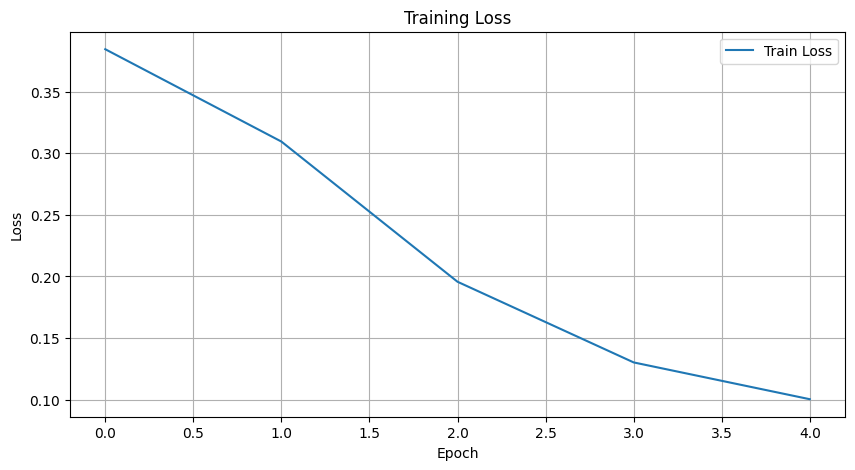

In [30]:
# Save final model
import os
os.makedirs("/content/models", exist_ok=True)
torch.save(trainer.model.state_dict(), "/content/models/simple_viton_final.pth")
print("✓ Model saved to: /content/models/simple_viton_final.pth")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(trainer.history["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("Training Loss")
plt.show()

trainer.save_history()

## Step 6: Test Inference


In [31]:
# Add infer method to trainer if missing
if not hasattr(trainer, 'infer'):
    from types import MethodType
    from torchvision import transforms
    import numpy as np
    
    def infer(self, person_img, garment_img):
        """Run inference on PIL images."""
        self.model.eval()
        
        transform = transforms.Compose([
            transforms.Resize((256, 192)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        person_t = transform(person_img).unsqueeze(0).to(self.device)
        garment_t = transform(garment_img).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            output = self.model(person_t, garment_t)
        
        output = output.squeeze(0).cpu()
        output = (output + 1) / 2
        output = (output * 255).byte().permute(1, 2, 0).numpy()
        return Image.fromarray(output)
    
    trainer.infer = MethodType(infer, trainer)
    print("✓ Added infer method to trainer")
else:
    print("✓ infer method already exists")

✓ Added infer method to trainer


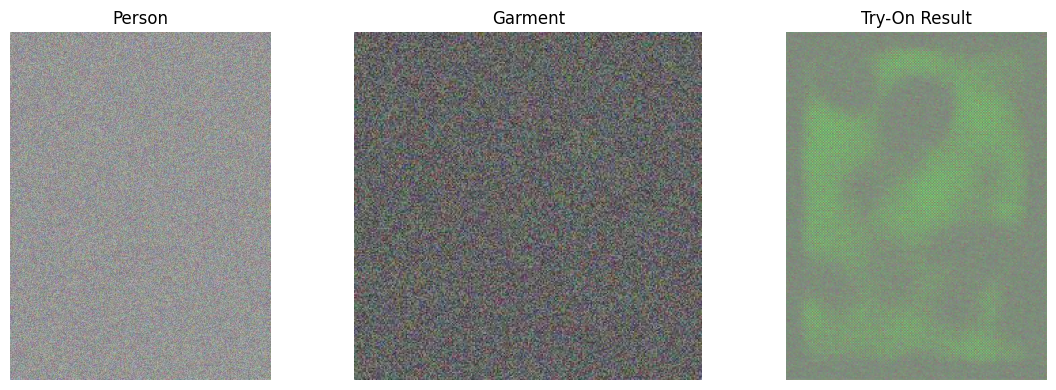

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

# Load a test sample
person_img = Image.open("/content/viton_data/person_images/img_0000.jpg")
garment_img = Image.open("/content/viton_data/garment_images/img_0000.jpg")

# Run inference
trainer.model.eval()
result = trainer.infer(person_img, garment_img)

# Display
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(person_img)
axes[0].set_title("Person")
axes[0].axis("off")

axes[1].imshow(garment_img)
axes[1].set_title("Garment")
axes[1].axis("off")

axes[2].imshow(result)
axes[2].set_title("Try-On Result")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Step 7: Download Trained Model


In [33]:
# Download the trained model
from google.colab import files
files.download("/content/models/simple_viton_final.pth")
print("✓ Model downloaded! Copy to backend/models/simple_viton_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Model downloaded! Copy to backend/models/simple_viton_final.pth


## Next Steps
1. Download `simple_viton_final.pth` 
2. Copy to `backend/models/simple_viton_final.pth`
3. Update FastAPI to use this model
4. Test the API
5. Once satisfied, train full model with VITON-HD dataset